# Partie D — Une stratégie sans biais d'anticipation

Le papier fait tourner une rotation entre des modèles factoriels construits sur QuantConnect.
Je les remplace, comme demandé, par les **facteurs de Kenneth French** (Mkt-RF, SMB, HML, MOM),
en journalier, plus SPY et le monétaire.

**Actifs** (rendements journaliers simples) :
- `SPY` : l'ETF, dividendes réinvestis ;
- `SMB`, `HML`, `MOM` : portefeuilles long/short à coût nul. L'investisseur place son capital au
  taux sans risque et superpose le long/short, donc rendement = RF + facteur ;
- `CASH` : le taux sans risque de French (T-bill 1 mois) ;
- `MKT` = Mkt-RF + RF est quasiment identique à SPY. Je l'affiche en D.1 mais je ne le garde pas
  comme actif investissable (doublon de SPY).

Le Sharpe est toujours calculé sur les rendements **en excès du T-bill** (le papier utilisait le
taux à 10 ans, ce qui n'est pas un taux sans risque à horizon d'un jour).

In [1]:
import sys
sys.path.insert(0, "..")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from src.features import build_features, Standardizer
from src.hmm_model import fit_hmm, sort_states, predicted_probs
from src.backtest import (WFConfig, walk_forward_regimes, regime_from_probs, weights_from_regime,
                          run_backtest, regime_conditional_stats, choose_mapping, rolling_mappings,
                          weights_from_rolling_mapping)
from src.allocation import max_sharpe_weights
from src.regimes import n_switches_per_year
from src.stats import stats_table, performance_stats
from src.pipeline import (spy_close, factor_returns, get_walk_forward, LEGS, TRAIN_START, TRAIN_END,
                          TEST_START, PAPER_TEST_END)
from src.plotting import (set_style, savefig, save_table, CATEGORICAL, REGIME_COLORS, REGIME_NAMES,
                          SHADE, INK_2, shade_regime)

set_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 180)

END = "2026-08-31"          # dernière date disponible dans les facteurs de K. French
R = factor_returns()
rf = R["CASH"]
ASSETS = ["SPY", "SMB", "HML", "MOM", "CASH"]
EX = R[["SPY", "MKT", "SMB", "HML", "MOM"]].sub(rf, axis=0)     # rendements en excès du T-bill
Q = ["q0", "q1", "q2"]
print(f"Données : {R.index[0].date()} -> {R.index[-1].date()}")

Données : 1993-02-01 -> 2026-08-31


## D.1 — Performance des facteurs dans chaque régime (période d'entraînement 2007–2017)

**Variables du HMM.** Pour la stratégie, j'utilise la **volatilité réalisée** (écart-type des
rendements sur 10 jours) à la place de la variance de prix du papier. Le notebook 02 a montré
que celle-ci dépend du niveau de l'indice ; en D.3 je montre ce que donnerait la stratégie
avec la variable du papier.

**Deux façons de relier régimes et rendements :**
- *même jour* (ce que fait le papier, Tables 5–7) : régime de Viterbi en $t$, rendement en $t$.
  Le régime est estimé avec toute la série **et** avec le rendement du jour lui-même ;
- *lendemain* (ce qui est exploitable) : régime **prédit** en $t$ à partir de $x_1..x_t$ (forward),
  rendement en $t+1$.

In [2]:
feat_real = build_features(spy_close(), "realized")
tr = feat_real.loc[TRAIN_START:TRAIN_END]
sc = Standardizer().fit(tr)
Ztr = sc.transform(tr.values)
m_tr, _ = sort_states(fit_hmm(Ztr, 3, n_init=10), "mean", feature=1)

reg_viterbi = pd.Series(m_tr.predict(Ztr), index=tr.index)
reg_pred = pd.Series(predicted_probs(m_tr, Ztr).argmax(1), index=tr.index)
ex_tr = EX.loc[TRAIN_START:TRAIN_END]

st_same = regime_conditional_stats(ex_tr, reg_viterbi, lag=0)
st_next = regime_conditional_stats(ex_tr, reg_pred, lag=1)
for name, st in [("MÊME JOUR, Viterbi (méthode du papier)", st_same), ("LENDEMAIN, régime prédit (exploitable)", st_next)]:
    tab = st["sharpe"].copy()
    tab.index = [REGIME_NAMES[k] for k in tab.index]
    tab["n_jours"] = st["n_jours"].values
    print(f"Sharpe annualisé par régime — {name}")
    display(tab.round(2))
save_table(pd.concat({"meme_jour": st_same, "lendemain": st_next}), "D1_stats_par_regime", ".3f")

Sharpe annualisé par régime — MÊME JOUR, Viterbi (méthode du papier)


,SPY,MKT,SMB,HML,MOM,n_jours
calme,2.03,1.99,0.13,0.28,0.66,1243
intermédiaire,0.29,0.29,0.12,-0.06,0.25,1062
crise,-0.23,-0.23,-0.03,-0.72,-0.76,381


Sharpe annualisé par régime — LENDEMAIN, régime prédit (exploitable)


,SPY,MKT,SMB,HML,MOM,n_jours
calme,0.68,0.70,-0.10,-0.31,0.86,1221
intermédiaire,0.82,0.81,0.38,0.36,-0.05,1086
crise,-0.03,-0.03,-0.08,-0.68,-0.54,378


In [3]:
detail = pd.concat({"moyenne ann.": st_next["moyenne"], "volatilité ann.": st_next["volatilite"],
                    "Sharpe": st_next["sharpe"]}, axis=1)
detail.index = [REGIME_NAMES[k] for k in detail.index]
print("Détail, relation 'lendemain' (rendements en excès, annualisés) :")
detail.round(3)

Détail, relation 'lendemain' (rendements en excès, annualisés) :


moyenne ann.                             volatilité ann.                             Sharpe                            
                       SPY    MKT    SMB    HML    MOM             SPY    MKT    SMB    HML    MOM    SPY    MKT    SMB    HML    MOM
calme                0.071  0.076 -0.008 -0.021  0.075           0.104  0.109  0.073  0.068  0.088  0.680  0.696 -0.104 -0.308  0.858
intermédiaire        0.141  0.144  0.033  0.035 -0.008           0.173  0.177  0.085  0.097  0.153  0.816  0.815  0.382  0.360 -0.050
crise               -0.014 -0.011 -0.013 -0.149 -0.169           0.414  0.409  0.156  0.219  0.315 -0.033 -0.027 -0.083 -0.684 -0.538

**Lecture.**
- En *même jour*, SPY a un Sharpe énorme en régime calme et négatif en crise. Mais cet effet
  est en grande partie **mécanique** : un jour de forte baisse augmente la volatilité mesurée, donc
  tend à être classé en crise. On mesure la conséquence (le rendement du jour) avec la variable
  qui en dépend.
- En *lendemain*, les écarts se réduisent fortement : SPY garde un Sharpe correct en calme et en
  régime intermédiaire, et **proche de zéro en crise**. HML et MOM sont très mauvais en crise
  (krach du momentum de 2009, bien documenté par Daniel & Moskowitz, 2016).

**Choix de l'allocation par régime** : l'actif de meilleur Sharpe « lendemain » dans chaque
régime, et le monétaire si aucun Sharpe n'est positif (fonction `choose_mapping`).

In [4]:
MAPPING = choose_mapping(st_next["sharpe"][["SPY", "SMB", "HML", "MOM"]], n_states=3)
for k, alloc in MAPPING.items():
    print(f"régime {k} ({REGIME_NAMES[k]:13s}) -> {alloc}")

régime 0 (calme        ) -> {'MOM': 1.0}
régime 1 (intermédiaire) -> {'SPY': 1.0}
régime 2 (crise        ) -> {'CASH': 1.0}


Mon mapping : **calme → MOM, intermédiaire → SPY, crise → CASH**. C'est cohérent avec l'intuition
(on sort du marché quand il est très agité), mais la décision en crise repose sur un Sharpe de SPY
à peine négatif, donc indiscernable de 0 vu l'erreur-type : c'est **fragile** (je le vérifie en D.5).

**Comparaison avec le papier (Tables 5 et 6, colonne S&P 500)**, en % journalier, avec les
variables du papier et la relation « même jour », pour être dans les mêmes conditions :

In [5]:
feat_pap = build_features(spy_close(), "paper").loc[TRAIN_START:TRAIN_END]
Zp = Standardizer().fit_transform(feat_pap)
m_p, _ = sort_states(fit_hmm(Zp.values, 3, n_init=10, n_iter=75, tol=1e-2), "mean", feature=1)
vit_p = pd.Series(m_p.predict(Zp.values), index=feat_pap.index)
spy_ex = 100 * EX["SPY"].loc[feat_pap.index[0]:feat_pap.index[-1]]
g = spy_ex.groupby(vit_p)
cmp5 = pd.DataFrame({"moyenne % (moi)": g.mean(), "moyenne % (papier)": [0.04517, 0.03956, -0.06607],
                     "écart-type % (moi)": g.std(), "écart-type % (papier)": [0.65726, 1.13402, 2.63856]},
                    index=[0, 1, 2])
cmp5.index = [REGIME_NAMES[k] for k in cmp5.index]
save_table(cmp5, "D1_spy_par_regime_vs_papier", ".4f")
cmp5

,moyenne % (moi),moyenne % (papier),écart-type % (moi),écart-type % (papier)
calme,0.049,0.045,0.654,0.657
intermédiaire,0.049,0.040,1.129,1.134
crise,-0.062,-0.066,2.643,2.639


Les rendements de SPY par régime reproduisent bien les Tables 5–6 du papier. Les petits écarts
viennent du taux sans risque retiré (T-bill chez moi, taux à 10 ans chez eux) et des dividendes.
On voit aussi que les Sharpe **journaliers** de la Table 7 (0,03 à 0,07) sont non annualisés :
multipliés par $\sqrt{252}$, ils donnent 0,5 à 1,1.

## D.2 — Protocole walk-forward

Chaque **mois** (code : `src/backtest.py`, fonction `walk_forward_regimes`) :
1. fenêtre d'entraînement = les **2 707 jours** de bourse qui précèdent **strictement** le premier jour
   du mois (même longueur que le papier) ;
2. standardisation avec la moyenne et l'écart-type **de cette fenêtre uniquement** ;
3. estimation du HMM (5 initialisations aléatoires + 1 initialisation à partir du modèle du
   mois précédent, on garde la meilleure vraisemblance) ;
4. tri des états par volatilité croissante (label switching, B.4) ;
5. pour chaque jour $t$ du mois : probabilité **filtrée** $P(S_t \mid x_{1..t})$ par mon forward,
   puis prédiction $P(S_{t+1} \mid x_{1..t}) = \hat\alpha_t A$ ;
6. l'allocation choisie à la clôture de $t$ est détenue pendant la journée $t+1$
   (`run_backtest` applique `weights.shift(1)`).

**Aucune donnée future** : ni Viterbi, ni `predict_proba` (lissé), ni standardisation globale.
Je le vérifie de trois façons : (a) tests unitaires `tests/test_no_lookahead.py` ; (b) ci-dessous, en
recalculant les probabilités de début 2020 avec des données **coupées** au 15 mars 2020 ;
(c) en vérifiant que les fenêtres d'entraînement se terminent avant chaque bloc.

In [6]:
probs_r, params_r, ins_r = get_walk_forward("realized", TEST_START, END, store_insample=True)
probs_p, params_p = get_walk_forward("paper", TEST_START, END)
print(f"{len(params_r)} réestimations mensuelles, de {params_r.index[0].date()} à {params_r.index[-1].date()}")
print("Toutes les fenêtres finissent avant leur bloc :", bool((params_r["train_end"] < params_r.index).all()))

# (b) recalcul avec les données tronquées au 15 mars 2020
cut = pd.Timestamp("2020-03-15")
feat_cut = build_features(spy_close().loc[:cut], "realized")
probs_cut, _ = walk_forward_regimes(feat_cut, "2020-01-01", cut, WFConfig(warm_start=False))
probs_ref, _ = walk_forward_regimes(feat_real, "2020-01-01", "2020-04-30", WFConfig(warm_start=False))
ecart = (probs_cut[Q] - probs_ref.loc[:cut, Q]).abs().max().max()
print(f"Écart max des probabilités jusqu'au 15/03/2020, données complètes vs tronquées : {ecart:.2e}")

108 réestimations mensuelles, de 2017-09-01 à 2026-08-03
Toutes les fenêtres finissent avant leur bloc : True


Écart max des probabilités jusqu'au 15/03/2020, données complètes vs tronquées : 7.23e-12


L'écart est nul : les probabilités utilisées pour trader en mars 2020 sont les mêmes, que l'on
connaisse ou non la suite de l'histoire.

### Stabilité des régimes d'une réestimation à l'autre

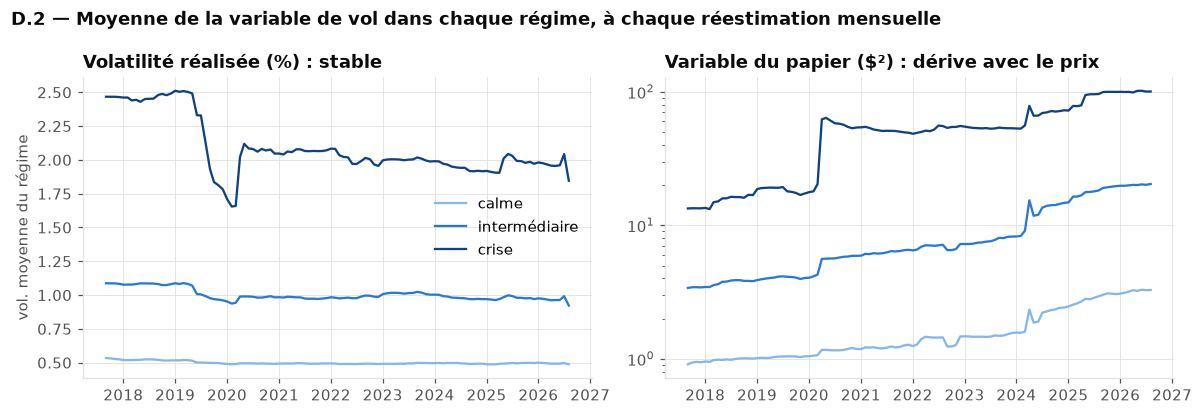

Durées moyennes 1/(1 - a_kk) des régimes sur les 108 réestimations (jours) :


,calme,intermédiaire,crise
mean,32.6,19.2,26.9
min,26.8,14.4,19.3
max,41.7,26.3,46.2


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for k in range(3):
    axes[0].plot(params_r.index, params_r[f"vol_moy_{k}"], color=REGIME_COLORS[k], label=REGIME_NAMES[k])
    axes[1].plot(params_p.index, params_p[f"vol_moy_{k}"], color=REGIME_COLORS[k], label=REGIME_NAMES[k])
axes[0].set_title("Volatilité réalisée (%) : stable")
axes[0].set_ylabel("vol. moyenne du régime")
axes[1].set_title("Variable du papier ($²) : dérive avec le prix")
axes[1].set_yscale("log")
axes[0].legend(loc="center right")
fig.suptitle("D.2 — Moyenne de la variable de vol dans chaque régime, à chaque réestimation mensuelle",
             x=0.01, ha="left", fontweight="bold", color="#0b0b0b")
fig.tight_layout()
savefig(fig, "D2_stabilite_regimes")
plt.show()

durees = params_r[["duree_0", "duree_1", "duree_2"]].describe().loc[["mean", "min", "max"]]
durees.columns = [REGIME_NAMES[k] for k in range(3)]
print("Durées moyennes 1/(1 - a_kk) des régimes sur les 108 réestimations (jours) :")
durees.round(1)

Avec la volatilité réalisée, les trois régimes gardent le même sens tout au long du test
(≈ 0,5 %, 1,0 % et 2,1 % d'écart-type journalier) : le tri par volatilité suffit à éviter le label
switching. Avec la variable du papier, le niveau moyen du régime de crise passe de ≈ 13 à
≈ 100 $² entre 2017 et 2026 (× 7), simplement parce que SPY est passé de 250 à plus de 700 $. Un « jour de crise »
de 2017 ressemble à un jour ordinaire de 2025.

### Probabilité de crise hors échantillon

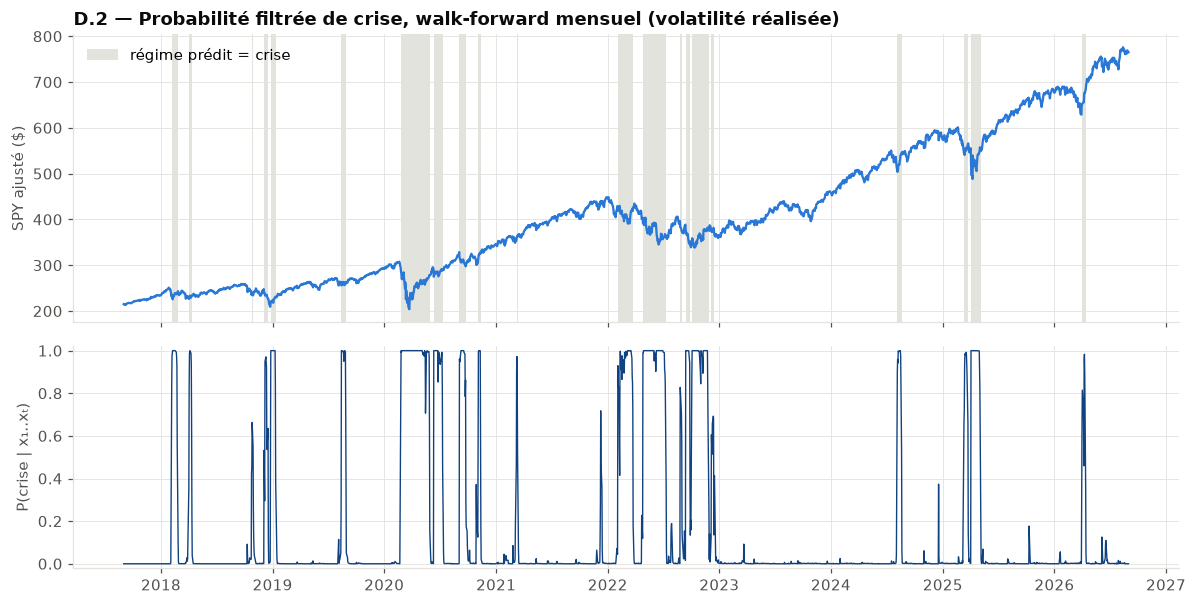

,calme,intermédiaire,crise,crise (variable du papier)
Date,,,,
2017,1.00,0.00,0.00,0.00
2018,0.54,0.32,0.14,0.49
2019,0.61,0.32,0.07,0.32
2020,0.23,0.35,0.43,0.63
2021,0.48,0.50,0.02,0.39
2022,0.00,0.43,0.57,0.96
2023,0.38,0.62,0.00,0.48
2024,0.53,0.42,0.04,0.33
2025,0.40,0.47,0.13,0.36


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]})
px = spy_close(adjusted=True).loc[TEST_START:END]
reg_r = regime_from_probs(probs_r[Q])
shade_regime(axes[0], reg_r, 2, label="régime prédit = crise")
axes[0].plot(px, color=CATEGORICAL[0])
axes[0].set_ylabel("SPY ajusté ($)")
axes[0].set_title("D.2 — Probabilité filtrée de crise, walk-forward mensuel (volatilité réalisée)")
axes[0].legend(loc="upper left")
axes[1].plot(probs_r["p2"], color=REGIME_COLORS[2], lw=0.9)
axes[1].set_ylabel("P(crise | x₁..xₜ)")
axes[1].set_ylim(-0.02, 1.02)
fig.tight_layout()
savefig(fig, "D2_proba_crise_oos")
plt.show()

freq = reg_r.groupby(reg_r.index.year).value_counts(normalize=True).unstack().fillna(0)
freq.columns = [REGIME_NAMES[k] for k in freq.columns]
freq_p = regime_from_probs(probs_p[Q])
freq_p = freq_p.groupby(freq_p.index.year).value_counts(normalize=True).unstack().fillna(0)
freq["crise (variable du papier)"] = freq_p.get(2, 0)
save_table(freq, "D2_frequence_regimes_par_annee", ".2f")
freq.round(2)

Les crises détectées correspondent aux épisodes connus : février 2018 (« Volmageddon »), décembre 2018,
août 2019, mars–mai 2020 (Covid), plusieurs phases de 2022 (hausse des taux), août 2024 et
avril 2025 (droits de douane). Avec la variable du papier, le régime de crise
occupe **96 % de 2022** et 30 à 60 % des autres années : il ne signifie plus grand-chose.

## D.3 — Backtest : septembre 2017 → avril 2020, puis jusqu'à août 2026

**Stratégies comparées :**
- **HMM** : allocation de D.1 selon le régime prédit (argmax de $P(S_{t+1} \mid x_{1..t})$) ;
- **HMM (variable du papier)** : même protocole avec la variance des prix, son mapping étant
  choisi de la même façon sur 2007–2017 ;
- **SPY** : achat-conservation ;
- **Statique optimisée** : portefeuille long-only de Sharpe maximal sur SPY/SMB/HML/MOM,
  estimé sur 2007–2017 puis figé (la « meilleure allocation statique » connue ex ante) ;
- **Meilleur actif ex post** : l'actif de meilleur Sharpe *sur la période de test* (référence
  « oracle », impossible à connaître à l'avance).

Frais : 0 et 10 points de base par unité de notionnel échangée (2 jambes pour un facteur long/short).

In [9]:
# mapping de la version "variable du papier", choisi exactement comme en D.1
reg_pred_p = pd.Series(predicted_probs(m_p, Zp.values).argmax(1), index=feat_pap.index)
MAPPING_P = choose_mapping(regime_conditional_stats(ex_tr, reg_pred_p, lag=1)["sharpe"][["SPY", "SMB", "HML", "MOM"]], n_states=3)
print("Mapping HMM (variable du papier) :", MAPPING_P)

W_static = max_sharpe_weights(ex_tr[["SPY", "SMB", "HML", "MOM"]])
print("Allocation statique optimisée sur 2007-2017 :", W_static.round(3).to_dict())

W_hmm = weights_from_regime(reg_r, MAPPING, ASSETS)
W_hmm_p = weights_from_regime(regime_from_probs(probs_p[Q]), MAPPING_P, ASSETS)
W_stat = pd.DataFrame([W_static.reindex(ASSETS).fillna(0).values] * len(W_hmm), index=W_hmm.index, columns=ASSETS)
W_spy = weights_from_regime(pd.Series(0, index=W_hmm.index), {0: {"SPY": 1.0}}, ASSETS)


def compare(end, cost=10):
    """Tableau de performance de toutes les stratégies sur [TEST_START, end]."""
    rets, ws = {}, {}
    for name, W in [("HMM", W_hmm), ("HMM (variable du papier)", W_hmm_p),
                    ("Statique optimisée 2007-17", W_stat), ("SPY", W_spy)]:
        Wc = W.loc[:end]
        rets[name + " — brut"] = run_backtest(Wc, R, 0, LEGS)["net"]
        ws[name + " — brut"] = Wc
        if name.startswith("HMM"):
            rets[name + f" — {cost} bp"] = run_backtest(Wc, R, cost, LEGS)["net"]
            ws[name + f" — {cost} bp"] = Wc
    idx = rets["SPY — brut"].index
    sharpe_assets = {a: performance_stats(R.loc[idx, a], rf)["sharpe"] for a in ["SPY", "SMB", "HML", "MOM"]}
    best = max(sharpe_assets, key=sharpe_assets.get)
    rets[f"Meilleur actif ex post ({best})"] = R.loc[idx, best]
    tab = stats_table(rets, rf, ws, LEGS, benchmark=R.loc[idx, "SPY"])
    return tab, rets


cols_show = ["rendement_annualise", "volatilite_annualisee", "sharpe", "sharpe_se", "max_drawdown",
             "pct_mois_positifs", "turnover_annuel", "ratio_information"]
tab_paper, rets_paper = compare(PAPER_TEST_END)
save_table(tab_paper[cols_show], "D3_backtest_periode_papier", ".3f")
print(f"Période du papier : {TEST_START} -> {PAPER_TEST_END}")
tab_paper[cols_show]

Mapping HMM (variable du papier) : {0: {'MOM': 1.0}, 1: {'SPY': 1.0}, 2: {'SPY': 1.0}}
Allocation statique optimisée sur 2007-2017 : {'SPY': 0.586, 'SMB': 0.079, 'HML': 0.0, 'MOM': 0.336}
Période du papier : 2017-09-01 -> 2020-04-30


,rendement_annualise,volatilite_annualisee,sharpe,sharpe_se,max_drawdown,pct_mois_positifs,turnover_annuel,ratio_information
HMM — brut,0.114,0.127,0.744,0.694,0.210,0.562,21.880,0.049
HMM — 10 bp,0.089,0.128,0.564,0.661,0.225,0.562,21.880,-0.055
HMM (variable du papier) — brut,0.041,0.225,0.197,0.620,0.337,0.625,41.874,-0.712
HMM (variable du papier) — 10 bp,-0.002,0.226,0.008,0.614,0.337,0.562,41.874,-1.417
Statique optimisée 2007-17 — brut,0.080,0.138,0.472,0.648,0.190,0.719,0.000,-0.183
SPY — brut,0.083,0.224,0.375,0.635,0.337,0.719,0.000,NaN
Meilleur actif ex post (MOM),0.073,0.134,0.436,0.643,0.156,0.469,NaN,-0.098


In [10]:
tab_full, rets_full = compare(END)
save_table(tab_full[cols_show], "D3_backtest_2017_2026", ".3f")
print(f"Période complète : {TEST_START} -> {END}")
tab_full[cols_show]

Période complète : 2017-09-01 -> 2026-08-31


,rendement_annualise,volatilite_annualisee,sharpe,sharpe_se,max_drawdown,pct_mois_positifs,turnover_annuel,ratio_information
HMM — brut,0.134,0.142,0.767,0.380,0.210,0.583,31.904,-0.136
HMM — 10 bp,0.099,0.143,0.540,0.358,0.225,0.565,31.904,-0.325
HMM (variable du papier) — brut,0.127,0.188,0.588,0.362,0.337,0.639,21.753,-0.566
HMM (variable du papier) — 10 bp,0.103,0.189,0.471,0.352,0.337,0.611,21.753,-1.104
Statique optimisée 2007-17 — brut,0.115,0.123,0.730,0.376,0.190,0.667,0.000,-0.416
SPY — brut,0.152,0.187,0.706,0.373,0.337,0.685,0.000,NaN
Meilleur actif ex post (SPY),0.152,0.187,0.706,0.373,0.337,0.685,NaN,NaN


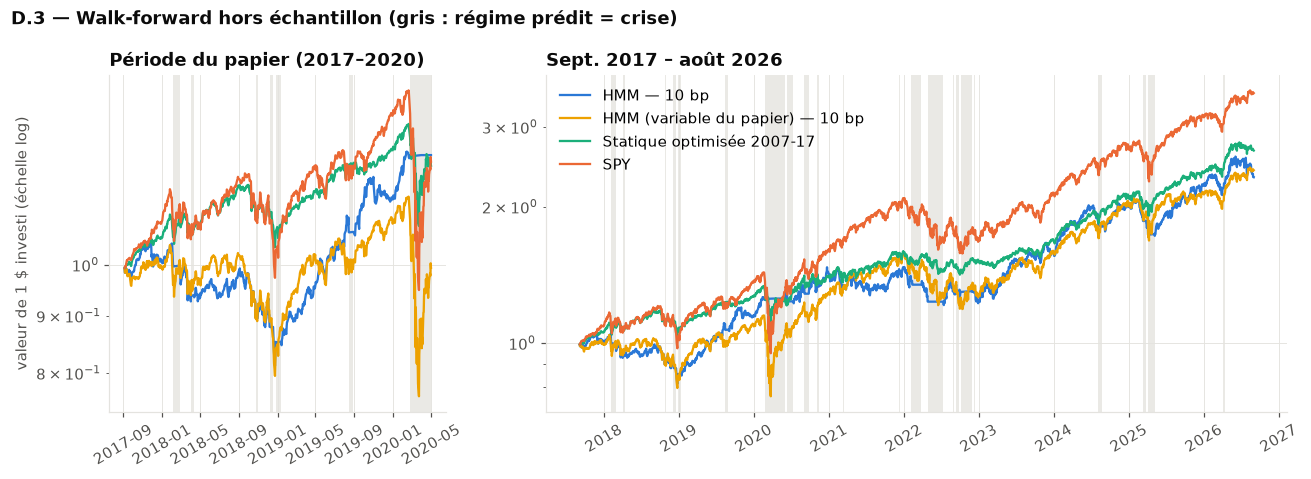

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1, 2.2]})
series = [("HMM — 10 bp", CATEGORICAL[0], "-"), ("HMM (variable du papier) — 10 bp", CATEGORICAL[3], "-"),
          ("Statique optimisée 2007-17 — brut", CATEGORICAL[2], "-"), ("SPY — brut", CATEGORICAL[1], "-")]
for ax, rets, titre in [(axes[0], rets_paper, "Période du papier (2017–2020)"),
                        (axes[1], rets_full, "Sept. 2017 – août 2026")]:
    shade_regime(ax, reg_r.loc[rets["SPY — brut"].index], 2, alpha=0.35)
    for name, col, ls in series:
        ax.plot((1 + rets[name]).cumprod(), color=col, ls=ls, label=name.replace(" — brut", ""))
    ax.set_title(titre)
    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("valeur de 1 $ investi (échelle log)")
axes[1].legend(loc="upper left")
fig.suptitle("D.3 — Walk-forward hors échantillon (gris : régime prédit = crise)", x=0.01, ha="left",
             fontweight="bold", color="#0b0b0b")
fig.tight_layout()
savefig(fig, "D3_courbes_capital")
plt.show()

**Résultats.**
- **Période du papier (sept. 2017 – avr. 2020)** : le HMM bat SPY en Sharpe (0,74 brut, 0,56
  avec 10 bp, contre 0,38 pour SPY), essentiellement parce qu'il passe en monétaire fin février 2020
  et évite le krach du Covid (max drawdown 21 % contre 34 %). Mais l'erreur-type du Sharpe
  (colonne `sharpe_se`) vaut ≈ 0,65–0,7 : sur 2,6 ans, **la différence n'est pas significative**.
  Le ratio d'information net de frais par rapport à SPY est d'ailleurs ≈ 0 (−0,06).
- **Jusqu'en 2026 (9 ans)** : l'avantage disparaît. Net de frais, le HMM fait **moins bien que SPY**
  (Sharpe 0,54 contre 0,71 ; 9,9 % par an contre 15,2 %). Le seul bénéfice qui reste est un
  drawdown maximal plus faible (22 % contre 34 %).
- **Avec la variable du papier**, la stratégie fait moins bien que SPY sur les deux périodes
  (Sharpe net ≈ 0 sur la période du papier) : le régime de crise est détecté beaucoup trop souvent (D.2).
- La **meilleure allocation statique** estimée sur 2007–2017 (59 % SPY, 34 % MOM, 8 % SMB) fait mieux que
  le HMM net de frais sur 2017–2026 (Sharpe 0,73 contre 0,54), sans aucun changement de position
  ni hypothèse sur les régimes.

On est **très loin du Sharpe de 2,0** du papier (discussion en D.5).

## D.4 — Frais de transaction et allers-retours

In [12]:
def switch_stats(reg, W):
    alloc_changes = (W.diff().abs().sum(axis=1) > 0).iloc[1:].sum() / (len(W) / 252)
    return n_switches_per_year(reg), alloc_changes


rows = []
for c in [0, 2, 5, 10, 20]:
    bt = run_backtest(W_hmm, R, c, LEGS)
    st = performance_stats(bt["net"], rf)
    rows.append({"frais (bp/jambe)": c, "rendement ann.": st["rendement_annualise"],
                 "Sharpe": st["sharpe"], "coût annuel moyen": bt["cost"].mean() * 252})
cost_tab = pd.DataFrame(rows).set_index("frais (bp/jambe)")
sw, ch = switch_stats(reg_r, W_hmm)
print(f"Changements de régime : {sw:.1f} par an | changements d'allocation : {ch:.1f} par an | "
      f"rotation annuelle (jambes) : {performance_stats(run_backtest(W_hmm, R)['net'], rf, W_hmm, LEGS)['turnover_annuel']:.1f}")
save_table(cost_tab, "D4_sensibilite_frais", ".3f")
cost_tab

Changements de régime : 14.3 par an | changements d'allocation : 14.3 par an | rotation annuelle (jambes) : 31.9


,rendement ann.,Sharpe,coût annuel moyen
frais (bp/jambe),,,
0,0.134,0.767,0.000
2,0.127,0.722,0.006
5,0.116,0.654,0.016
10,0.099,0.540,0.032
20,0.064,0.313,0.064


Environ **14 changements de régime par an** (un toutes les 3–4 semaines). Chaque passage
MOM ↔ SPY coûte 3 unités de notionnel (2 jambes MOM + 1 SPY). À 10 bp, les frais coûtent
≈ 3,2 points de rendement par an et le Sharpe baisse de 30 % (0,77 → 0,54). À 20 bp, il tombe à 0,31,
très en dessous de SPY. Et ces frais ne comptent que les changements de régime : la rotation
interne des portefeuilles de French (rééquilibrages annuels ou mensuels, surtout pour MOM) n'est pas
comptée, les rendements des facteurs sont bruts de frais.

### Comment limiter les allers-retours ?

Toutes ces règles sont **causales** (fonction `regime_from_probs`, testée dans `tests/`) :
- **seuil / hystérésis** : on ne change de régime que si la probabilité du nouveau dépasse 0,7 ou 0,9 ;
- **lissage** : moyenne mobile exponentielle des probabilités (demi-vie courte) avant l'argmax ;
- **durée minimale** : on reste au moins 5 ou 10 jours dans un régime après un changement ;
- **rééquilibrage mensuel** : l'allocation n'est revue que le dernier jour du mois (lecture
  littérale de « chaque mois » dans D.2).

In [13]:
variants = {"argmax (référence)": {}, "seuil 0,7": dict(threshold=0.7), "seuil 0,9": dict(threshold=0.9),
            "lissage EMA 5 j": dict(ema_span=5), "lissage EMA 10 j": dict(ema_span=10),
            "durée min. 5 j": dict(min_duration=5), "durée min. 10 j": dict(min_duration=10),
            "rééquilibrage mensuel": dict(rebalance="M")}
rows = []
for name, kw in variants.items():
    reg_v = regime_from_probs(probs_r[Q], **kw)
    W_v = weights_from_regime(reg_v, MAPPING, ASSETS)
    s0 = performance_stats(run_backtest(W_v, R, 0, LEGS)["net"], rf)
    s10 = performance_stats(run_backtest(W_v, R, 10, LEGS)["net"], rf)
    sw, ch = switch_stats(reg_v, W_v)
    rows.append({"variante": name, "changements régime / an": sw, "changements alloc. / an": ch,
                 "Sharpe brut": s0["sharpe"], "Sharpe 10 bp": s10["sharpe"],
                 "rdt ann. 10 bp": s10["rendement_annualise"], "max DD 10 bp": s10["max_drawdown"]})
var_tab = pd.DataFrame(rows).set_index("variante")
save_table(var_tab, "D4_variantes_anti_allers_retours", ".3f")
var_tab

,changements régime / an,changements alloc. / an,Sharpe brut,Sharpe 10 bp,rdt ann. 10 bp,max DD 10 bp
variante,,,,,,
argmax (référence),14.273,14.273,0.767,0.540,0.099,0.225
"seuil 0,7",12.265,12.265,0.676,0.472,0.088,0.224
"seuil 0,9",11.150,11.150,0.797,0.610,0.108,0.163
lissage EMA 5 j,12.377,12.377,0.772,0.569,0.102,0.228
lissage EMA 10 j,11.262,11.262,0.789,0.605,0.108,0.206
durée min. 5 j,13.604,13.604,0.842,0.619,0.111,0.224
durée min. 10 j,12.600,12.600,0.825,0.623,0.114,0.216
rééquilibrage mensuel,6.244,6.244,0.990,0.887,0.158,0.205


- Le seuil, le lissage et la durée minimale réduisent un peu les allers-retours (14 → 11–13 par
  an) et améliorent en général légèrement le Sharpe net, sauf le seuil à 0,7. Le **rééquilibrage
  mensuel** divise les changements par plus de deux (≈ 6 par an) et donne ici le meilleur Sharpe net (0,89).
- **Attention au piège** : j'ai testé 8 variantes *sur la période de test*. Retenir la meilleure
  après coup, ce serait optimiser sur le test : son Sharpe serait biaisé vers le haut (c'est
  exactement ce que je reproche au papier). Ma stratégie de référence reste l'argmax, fixée
  **avant** de voir ces résultats. Ce tableau sert d'analyse de sensibilité : les variantes donnent
  un Sharpe net entre 0,47 et 0,89, autour de celui de SPY (0,71), donc la conclusion « pas mieux que
  SPY de façon significative » ne dépend pas de ce réglage.

**Hypothèse d'exécution.** Je suppose qu'on trade au prix de clôture du jour où le signal est
calculé (ordre « market-on-close », avec le prix de clôture presque connu quelques minutes avant).
Si l'on ne peut trader que le lendemain :

In [14]:
lag_rows = {}
for lag in [0, 1, 2]:
    W_l = W_hmm.shift(lag).dropna()
    lag_rows[f"exécution +{lag} j"] = performance_stats(run_backtest(W_l, R, 10, LEGS)["net"], rf)[
        ["rendement_annualise", "sharpe", "max_drawdown"]]
lag_tab = pd.DataFrame(lag_rows).T
save_table(lag_tab, "D4_retard_execution", ".3f")
lag_tab

,rendement_annualise,sharpe,max_drawdown
exécution +0 j,0.099,0.540,0.225
exécution +1 j,0.112,0.627,0.221
exécution +2 j,0.111,0.629,0.211


Retarder l'exécution d'un ou deux jours ne dégrade pas le résultat. Il s'améliore même un peu
(0,63 contre 0,54), ce qui ne peut être que du hasard : le signal repose sur une volatilité
persistante, pas sur une information qui disparaît en un jour. C'est rassurant (pas de fuite
d'information cachée dans le timing), et cela donne une idée du **bruit** : ±0,1 de Sharpe
sans rien changer au fond de la stratégie.

## D.5 — Conclusion critique : pourquoi suis-je si loin d'un Sharpe de 2 ?

### 1. Le mapping appris sur 2007–2017 est-il robuste ?
Je refais le walk-forward **complet** : à chaque réestimation, la table régime → actif est
réapprise sur la seule fenêtre d'entraînement (`rolling_mappings`). Le test peut alors commencer
bien plus tôt, **dès janvier 2004** (22,7 ans, avec 2008), sans aucune fuite d'information.
J'ajoute une règle **fixée a priori**, sans rien apprendre : « SPY, sauf en régime de crise → monétaire »
(*volatility timing*).

In [15]:
probs_L, params_L, ins_L = get_walk_forward("realized", "2004-01-02", END, store_insample=True)
maps_L = rolling_mappings(ins_L, EX[["SPY", "SMB", "HML", "MOM"]], 3)
reg_L = regime_from_probs(probs_L[Q])
W_L = weights_from_rolling_mapping(reg_L, probs_L["refit_date"], maps_L, ASSETS)
W_vt = weights_from_regime(reg_L, {0: {"SPY": 1.0}, 1: {"SPY": 1.0}, 2: {"CASH": 1.0}}, ASSETS)

rets_L = {"HMM rotation factorielle (mapping glissant) — 10 bp": run_backtest(W_L, R, 10, LEGS)["net"],
          "HMM rotation factorielle (mapping glissant) — brut": run_backtest(W_L, R, 0, LEGS)["net"],
          "SPY sauf crise → cash — 10 bp": run_backtest(W_vt, R, 10, LEGS)["net"]}
idx_L = rets_L["SPY sauf crise → cash — 10 bp"].index
for a in ["SPY", "SMB", "HML", "MOM"]:
    rets_L[a] = R.loc[idx_L, a]
tab_L = stats_table(rets_L, rf, {"HMM rotation factorielle (mapping glissant) — 10 bp": W_L,
                                 "SPY sauf crise → cash — 10 bp": W_vt}, LEGS, benchmark=R.loc[idx_L, "SPY"])
save_table(tab_L[cols_show], "D5_test_long_2004_2026", ".3f")
print(f"Test long : {idx_L[0].date()} -> {idx_L[-1].date()}")
tab_L[cols_show]

Test long : 2004-01-05 -> 2026-08-31


,rendement_annualise,volatilite_annualisee,sharpe,sharpe_se,max_drawdown,pct_mois_positifs,turnover_annuel,ratio_information
HMM rotation factorielle (mapping glissant) — 10 bp,0.006,0.174,0.022,0.210,0.652,0.540,34.484,-0.726
HMM rotation factorielle (mapping glissant) — brut,0.042,0.173,0.222,0.213,0.549,0.570,NaN,-0.476
SPY sauf crise → cash — 10 bp,0.100,0.126,0.682,0.233,0.358,0.647,4.156,-0.128
SPY,0.109,0.186,0.555,0.226,0.552,0.669,NaN,NaN
SMB,0.010,0.098,-0.027,0.210,0.280,0.526,NaN,-0.538
HML,0.012,0.124,0.014,0.210,0.535,0.471,NaN,-0.484
MOM,0.028,0.167,0.145,0.211,0.633,0.592,NaN,-0.288


In [16]:
mp_count = pd.Series({d: " | ".join(f"{REGIME_NAMES[k]}→{list(v)[0]}" for k, v in m.items())
                      for d, m in maps_L.items()}).value_counts()
print(f"Tables régime -> actif choisies au fil des {len(maps_L)} réestimations (nombre de mois) :")
mp_count.head(8).to_frame("mois")

Tables régime -> actif choisies au fil des 272 réestimations (nombre de mois) :


,mois
calme→MOM | intermédiaire→SPY | crise→SPY,86
calme→HML | intermédiaire→HML | crise→SPY,34
calme→MOM | intermédiaire→HML | crise→SPY,30
calme→MOM | intermédiaire→SPY | crise→SMB,19
calme→SPY | intermédiaire→SPY | crise→SMB,13
calme→HML | intermédiaire→SMB | crise→CASH,12
calme→MOM | intermédiaire→MOM | crise→SPY,11
calme→SPY | intermédiaire→SPY | crise→SPY,8


In [17]:
sub = []
for a, b in [("2004", "2007"), ("2008", "2009"), ("2010", "2016"), ("2017", "2020-04"), ("2020-05", "2026")]:
    row = {"période": f"{a} → {b}"}
    for name, r in [("HMM rotation (10 bp)", rets_L["HMM rotation factorielle (mapping glissant) — 10 bp"]),
                    ("SPY sauf crise → cash (10 bp)", rets_L["SPY sauf crise → cash — 10 bp"]), ("SPY", rets_L["SPY"])]:
        row[name] = performance_stats(r.loc[a:b], rf)["sharpe"]
    sub.append(row)
sub = pd.DataFrame(sub).set_index("période")
save_table(sub, "D5_sharpe_sous_periodes", ".2f")
print("Sharpe par sous-période :")
sub

Sharpe par sous-période :


,HMM rotation (10 bp),SPY sauf crise → cash (10 bp),SPY
période,,,
2004 → 2007,-0.087,0.429,0.502
2008 → 2009,-0.679,-0.338,-0.177
2010 → 2016,-0.217,1.030,0.855
2017 → 2020-04,-0.092,0.668,0.500
2020-05 → 2026,0.704,0.778,0.898


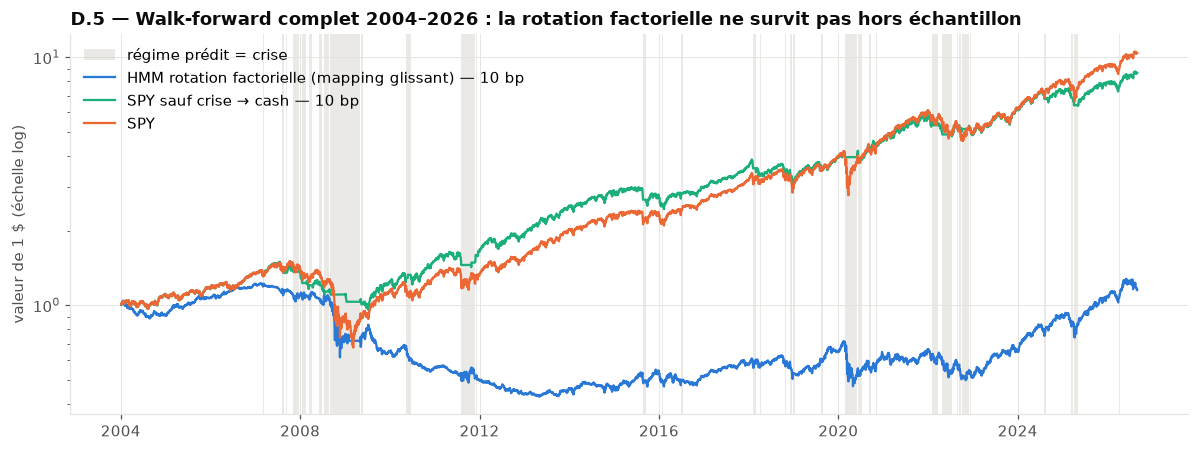

In [18]:
fig, ax = plt.subplots(figsize=(11, 4.2))
shade_regime(ax, reg_L.loc[idx_L], 2, alpha=0.35, label="régime prédit = crise")
for name, col in [("HMM rotation factorielle (mapping glissant) — 10 bp", CATEGORICAL[0]),
                  ("SPY sauf crise → cash — 10 bp", CATEGORICAL[2]), ("SPY", CATEGORICAL[1])]:
    ax.plot((1 + rets_L[name]).cumprod(), color=col, label=name)
ax.set_yscale("log")
ax.set_ylabel("valeur de 1 $ (échelle log)")
ax.set_title("D.5 — Walk-forward complet 2004–2026 : la rotation factorielle ne survit pas hors échantillon")
ax.legend(loc="upper left")
fig.tight_layout()
savefig(fig, "D5_test_long")
plt.show()

**C'est le résultat le plus important du projet.**
- Quand le choix des facteurs est lui aussi fait hors échantillon, la **rotation factorielle**
  s'effondre : Sharpe ≈ 0,2 brut et ≈ 0 avec frais sur 22 ans, contre ≈ 0,56 pour SPY. La table
  régime → facteur change sans cesse d'une fenêtre à l'autre (HML, MOM, SMB, SPY, cash...) : elle
  capte surtout le bruit de chaque fenêtre, comme on pouvait s'y attendre au vu des faibles t-stats de C.2.
- La règle **« SPY sauf en crise »**, qui n'optimise rien, donne un Sharpe de 0,68 net de frais
  (contre 0,56 pour SPY) et réduit le drawdown maximal (36 % contre 55 %). Elle ne bat SPY que sur
  2 des 5 sous-périodes (2010–2016 et 2017–2020), et l'écart de Sharpe (0,13) reste inférieur à une
  erreur-type (≈ 0,23) : c'est surtout une réduction du risque, pas un surplus de rendement. C'est le seul effet robuste : **réduire l'exposition quand la volatilité est
  élevée**, comme dans la littérature sur le *volatility timing* (Moreira & Muir, 2017). Il ne marche
  pas partout : en 2008–2009, sortir en crise fait rater le rebond de mars 2009, et le Sharpe reste
  négatif.
- Le « bon » mapping de la section D.3 (crise → cash) n'était retenu en 2017 qu'à une
  décimale près ; avec plus de données, les fenêtres suivantes choisissent le plus souvent SPY en crise.

### 2. Mars 2020 : combien de jours de retard ?

In [19]:
win = probs_r.loc["2020-02-12":"2020-03-06", ["p0", "p1", "p2"]].copy()
win.columns = [f"P({REGIME_NAMES[k]})" for k in range(3)]
win["rendement SPY (%)"] = 100 * R.loc[win.index, "SPY"]
win["régime retenu"] = reg_r.loc[win.index].map(REGIME_NAMES)
win.round(3)

,P(calme),P(intermédiaire),P(crise),rendement SPY (%),régime retenu
Date,,,,,
2020-02-12,0.000,0.998,0.002,0.644,intermédiaire
2020-02-13,0.000,0.998,0.001,-0.107,intermédiaire
2020-02-14,0.388,0.610,0.002,0.160,intermédiaire
2020-02-18,0.774,0.225,0.000,-0.258,calme
2020-02-19,0.995,0.005,0.000,0.478,calme
2020-02-20,1.000,0.000,0.000,-0.411,calme
2020-02-21,0.991,0.009,0.000,-1.030,calme
2020-02-24,0.000,0.306,0.694,-3.317,crise
2020-02-25,0.000,0.001,0.999,-3.030,crise


In [20]:
out = reg_r.loc["2020-02-24":]
first_exit = out[out != 2].index[0]
spy_c = spy_close(adjusted=True)
print(f"Plus haut de SPY : 19/02/2020 ; 1er jour de forte baisse : 24/02/2020 ({100 * R.loc['2020-02-24', 'SPY']:.1f} %)")
print(f"P(crise) > 0.5 à la clôture du 24/02/2020 -> en monétaire dès le 25/02")
print(f"Perte de SPY entre le plus haut et la sortie : {100 * (spy_c['2020-02-24'] / spy_c['2020-02-19'] - 1):.1f} %")
print(f"Perte de SPY du 24/02 au plus bas du 23/03 : {100 * (spy_c['2020-03-23'] / spy_c['2020-02-24'] - 1):.1f} %")
print(f"Premier jour hors régime de crise : {first_exit.date()} ; "
      f"SPY entre le plus bas du 23/03 et cette date : {100 * (spy_c[first_exit] / spy_c['2020-03-23'] - 1):.1f} %")

Plus haut de SPY : 19/02/2020 ; 1er jour de forte baisse : 24/02/2020 (-3.3 %)
P(crise) > 0.5 à la clôture du 24/02/2020 -> en monétaire dès le 25/02
Perte de SPY entre le plus haut et la sortie : -4.7 %
Perte de SPY du 24/02 au plus bas du 23/03 : -30.4 %
Premier jour hors régime de crise : 2020-05-29 ; SPY entre le plus bas du 23/03 et cette date : 36.5 %


Le HMM détecte la crise **à la clôture du premier jour de forte baisse** (24 février, −3,3 %), soit
3 jours de bourse après le plus haut du 19 février ; SPY avait alors déjà perdu 4,7 %. Cela a
été utile : la stratégie est en monétaire dès le 25 février et évite l'essentiel de la chute
(−30 % du 24 février au 23 mars). Mais le retard existe aussi **à la sortie** : le régime de crise
ne se termine que le **29 mai 2020**, alors que SPY a déjà rebondi de **+36 %** depuis son plus bas.
Un HMM sur la volatilité est lent dans les deux sens. En mars 2020, la baisse a duré assez
longtemps pour que ce retard soit rentable. Sur un krach éclair qui rebondit en quelques jours (août 2024),
on sortirait au plus bas et on raterait le rebond.

### 3. Régression sur les facteurs (comparaison avec la Table 8 du papier)

In [21]:
y = rets_full["HMM — 10 bp"] - rf.reindex(rets_full["HMM — 10 bp"].index)
# facteurs de French : (RF + facteur) - RF = facteur
fac = R[["MKT", "SMB", "HML", "MOM"]].sub(rf, axis=0).rename(columns={"MKT": "MKT-RF"}).loc[y.index]
Xf = sm.add_constant(fac)
ols = sm.OLS(y, Xf).fit(cov_type="HAC", cov_kwds={"maxlags": 10})
reg_tab = pd.DataFrame({"coef": ols.params, "t (Newey-West)": ols.tvalues})
reg_tab.loc["const", "coef"] *= 252
reg_tab = reg_tab.rename(index={"const": "alpha annualisé"})
save_table(reg_tab, "D5_regression_facteurs", ".3f")
reg_tab

,coef,t (Newey-West)
alpha annualisé,0.019,0.502
MKT-RF,0.372,5.082
SMB,0.052,1.356
HML,-0.091,-1.920
MOM,0.219,5.167


Le papier trouve un alpha annuel très significatif (t = 3,3). Ici, sur 9 ans hors échantillon
et net de frais, l'alpha n'est **pas significatif** : la performance de la stratégie s'explique
par son exposition moyenne au marché et au momentum.

### 4. Synthèse : d'où vient l'écart avec le Sharpe de 2,0 du papier ?

| Choix du papier | Mon choix | Effet sur le Sharpe |
|---|---|---|
| 6 modèles factoriels « maison » sur QuantConnect (sélection d'actions, levier ×2 pour Value) | facteurs Fama-French publics, sans levier | le Sharpe du papier vient surtout du modèle Value à levier (53 % de rendement sur la période) et du fait d'avoir choisi *après coup* les deux modèles entre lesquels alterner |
| régimes interprétés avec les rendements du **même jour** | relation **lendemain** | supprime la part mécanique de la relation régime → rendement |
| règle de détection ad hoc (KS, seuils de densité 0,3 / 0,5) | probabilité filtrée du HMM | seuils non justifiés, probablement ajustés : la mienne n'a aucun paramètre libre |
| variance des **prix** ($²) | volatilité des **rendements** | avec leur variable, la stratégie reste en crise sur une grande partie du test (D.2–D.3) |
| pas de frais mentionnés | 10 bp par jambe | −0,2 environ de Sharpe |
| taux à 10 ans comme taux sans risque | T-bill 1 mois | change le niveau des Sharpe |
| un seul test de 2,6 ans avec un krach (Covid) évité | 2,6 ans, 9 ans et 22,7 ans | l'effet « éviter le Covid » est un seul événement ; sur 22 ans, la rotation ne bat pas SPY |

**Conclusion.** Mon Sharpe hors échantillon (0,56 net sur la période du papier, 0,54 net sur
2017–2026, et ≈ 0 pour la rotation factorielle entièrement walk-forward sur 2004–2026) est
**près de 4 fois plus faible** que le 2,0 du papier, et n'est jamais significativement supérieur à
celui de SPY. Je ne peux pas reproduire leurs modèles QuantConnect, mais la plupart des différences vont dans
le même sens : le chiffre du papier est très probablement **surestimé**. Ce qui résiste à un protocole
propre est modeste : un HMM sur la volatilité permet de **réduire l'exposition dans les périodes très
agitées**, ce qui baisse surtout le drawdown, avec un gain de Sharpe incertain.